# Corporate Wallet Digital Twin V2.1 - reproducible judging notebook

**Team:** Corporate Wallet Digital Twin  
**Team member:** Christopher Koen  
**Event:** Standard Bank Hackathon 2026

This notebook is the reproducible evidence spine for the submission. It keeps observed activity, identified bounds, posterior estimates, governed commercial scenarios and causal claims separate. All displayed commercial values use Syn Bank simulation and representative benchmark inputs; they are not bank-approved pricing or measured competitor share.

## 1. Load the frozen, point-in-time judging artifacts

The confidential supplied archive is not required to review this notebook. Aggregate outputs retain their source and transformation versions. Set `SYNBANK_DATA_ZIP` and run `python scripts/run_judging_validation.py` to rebuild the transaction-history layer.

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

def load_json(relative):
    return json.loads((ROOT / relative).read_text(encoding='utf-8'))

portfolio = load_json('outputs/data/portfolio.json')
manifest = load_json('outputs/client_demo/client_demo_data_manifest.json')
scorecard = load_json('outputs/client_demo/client_demo_scorecard.json')
offline = load_json('outputs/v2_validation/offline_validation_report.json')
genai = load_json('outputs/v2_validation/genai_golden_eval.json')
evidence_qa = load_json('outputs/v2_validation/public_evidence_qa.json')
fixture = load_json('dashboard/app/data/shadow-fixture.json')
submission = load_json('config/submission.json')

assert manifest['source_estate']['synbank_rows'] == 3_064_295
assert manifest['source_estate']['audited_public_e1_facts'] == 82
assert fixture['sensitivity']['draws'] == 10_000
assert genai['governed_evaluation_checks'] == 809
print(f"Loaded {submission['solution_version']} as of {submission['as_of']} - all headline assertions passed.")
print('Repository:', submission['repository_url'])

Loaded V2.1 as of 2026-08-09 - all headline assertions passed.
Repository: https://github.com/ChristopherJohannesKoen/corporate-wallet-digital-twin-hackathon-2026


## 2. Data estate and claim boundary

The data estate is deliberately plural: supplied Syn Bank activity, page-grounded E1 evidence and explicitly representative calibration references. None of the latter is relabelled as real E3 competitor observation.

In [2]:
estate = manifest['source_estate']
estate_table = pd.DataFrame([
    ['Syn Bank simulation', estate['synbank_rows'], 'Observed bank activity inside the supplied simulation'],
    ['Public E1 facts', estate['audited_public_e1_facts'], 'Point-in-time anchors across all 20 relationships'],
    ['Known-truth multibank analog', manifest['representative_panel']['observations'], 'Model-mechanics calibration only; not E3'],
    ['Trade-finance reference', estate['representative_trade_finance_rows'], 'Representative process benchmark'],
    ['FinQA reasoning cases', estate['finqa_numerical_reasoning_cases'], 'External numerical-reasoning reference'],
], columns=['Layer', 'Records / facts', 'Permitted interpretation'])
display(estate_table.style.format({'Records / facts': '{:,.0f}'}))
print('Client-demo release:', scorecard['client_demo_release_allowed'])
print('Bank-production release:', scorecard['bank_production_release_allowed'])
print('Human approvals completed for 51 expanded facts:', evidence_qa['human_approvals_completed'])

,Layer,Records / facts,Permitted interpretation
0,Syn Bank simulation,"3,064,295",Observed bank activity inside the supplied simulation
1,Public E1 facts,82,Point-in-time anchors across all 20 relationships
2,Known-truth multibank analog,"1,500",Model-mechanics calibration only; not E3
3,Trade-finance reference,"10,000",Representative process benchmark
4,FinQA reasoning cases,"8,281",External numerical-reasoning reference


Client-demo release: True
Bank-production release: False
Human approvals completed for 51 expanded facts: 0


### Identification contract

For product activity $A$, bank share $q$ and total wallet $T$:

$$A = qT$$

One observed quantity cannot identify two unknowns. The system therefore reports: observed $A$; assumption-light bounds; a prior-conditioned posterior for $q$ and $T$; and a separate commercial scenario. This avoids presenting an accounting proxy as an exact wallet label.

## 3. Portfolio decision: who, what, when and why

The following ranking is a governed scenario using the frozen benchmark economics. `P(top 10)` expresses rank uncertainty, not win probability.

In [3]:
ranked = sorted(portfolio['opportunities'], key=lambda row: row['priority_score'], reverse=True)[:10]
top10 = pd.DataFrame([{
    'rank': rank,
    'client': row['entity_name'],
    'product': row['product'],
    'observed_Rbn': row['observed_activity_zar'] / 1e9,
    'wallet_median_Rbn': row['total_wallet_zar']['p50'] / 1e9,
    'scenario_gap_Rm': row['revenue_gap_zar']['p50'] / 1e6,
    'P_top10': row['top10_probability'],
    'evidence': 'E1 anchor' if row['anchor_impact']['active'] else 'E0 prior-led',
} for rank, row in enumerate(ranked, 1)])
display(top10.style.format({
    'observed_Rbn': '{:.2f}', 'wallet_median_Rbn': '{:.1f}',
    'scenario_gap_Rm': '{:.1f}', 'P_top10': '{:.0%}'
}))

,rank,client,product,observed_Rbn,wallet_median_Rbn,scenario_gap_Rm,P_top10,evidence
0,1,Glencore,Trade finance,1.09,77.7,146.6,100%,E1 anchor
1,2,Glencore,Collections,2.46,1514.6,82.3,100%,E1 anchor
2,3,Glencore,Cross-border FX,2.32,166.9,62.8,100%,E1 anchor
3,4,Glencore,Payments,1.88,1441.2,50.4,100%,E1 anchor
4,5,BHP Group,Cross-border FX,2.08,119.5,45.4,100%,E1 anchor
5,6,Glencore,Liquidity,2.17,152.2,37.6,100%,E1 anchor
6,7,BHP Group,Trade finance,1.44,15.3,22.1,99%,E1 anchor
7,8,BHP Group,Collections,9.19,506.7,26.4,99%,E1 anchor
8,9,BHP Group,Payments,7.14,331.9,11.0,72%,E1 anchor
9,10,Shoprite Holdings,Collections,2.67,141.6,7.3,45%,E1 anchor


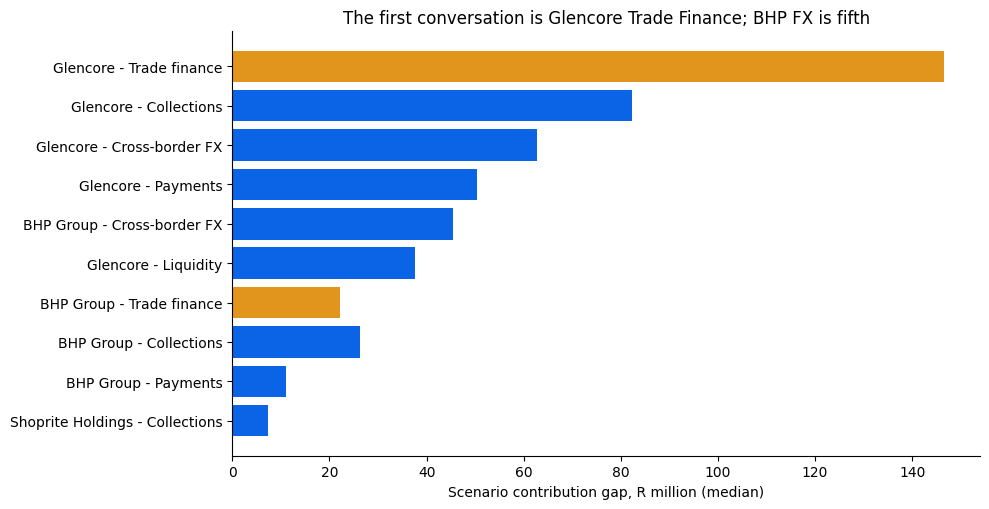

In [4]:
plot_data = top10.iloc[::-1]
colors = ['#E2951C' if p == 'Trade finance' else '#0B63E5' for p in plot_data['product']]
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.barh(plot_data['client'] + ' - ' + plot_data['product'], plot_data['scenario_gap_Rm'], color=colors)
ax.set_xlabel('Scenario contribution gap, R million (median)')
ax.set_title('The first conversation is Glencore Trade Finance; BHP FX is fifth')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. BHP worked twin: additional evidence narrows uncertainty

BHP is the auditable walkthrough. Accounting, FX and current-debt facts are treated as noisy product anchors with page, reporting-period and availability dates.

In [5]:
bhp = [row for row in portfolio['opportunities'] if row['entity_id'] == 'E01']
bhp_table = pd.DataFrame([{
    'product': row['product'],
    'observed_Rbn': row['observed_activity_zar'] / 1e9,
    'share_median': row['current_share']['p50'],
    'wallet_median_Rbn': row['total_wallet_zar']['p50'] / 1e9,
    'scenario_gap_Rm': row['revenue_gap_zar']['p50'] / 1e6,
    'interval_narrowing': row['anchor_impact']['relative_interval_width_reduction'],
    'confidence_lift': row['anchor_impact']['confidence_lift'],
    'source_pages': '; '.join(row['public_anchor']['source_pages']),
    'available_date': row['public_anchor']['available_date'],
} for row in sorted(bhp, key=lambda x: x['priority_score'], reverse=True)])
display(bhp_table.style.format({
    'observed_Rbn': '{:.2f}', 'share_median': '{:.1%}',
    'wallet_median_Rbn': '{:.1f}', 'scenario_gap_Rm': '{:.1f}',
    'interval_narrowing': '{:.1%}', 'confidence_lift': '+{:.0%}'
}))

,product,observed_Rbn,share_median,wallet_median_Rbn,scenario_gap_Rm,interval_narrowing,confidence_lift,source_pages,available_date
0,Cross-border FX,2.08,1.7%,119.5,45.4,41.2%,+26%,BHP Annual Report 2025 p.160,2025-08-19
1,Trade finance,1.44,9.5%,15.3,22.1,49.2%,+26%,BHP Annual Report 2025 p.118; BHP Annual Report 2025 p.139,2025-08-19
2,Collections,9.19,1.8%,506.7,26.4,80.5%,+26%,BHP Annual Report 2025 p.118; BHP Annual Report 2025 p.139,2025-08-19
3,Payments,7.14,2.1%,331.9,11.0,80.5%,+26%,BHP Annual Report 2025 p.118; BHP Annual Report 2025 p.139,2025-08-19
4,Liquidity,8.16,22.7%,36.0,3.9,70.1%,+26%,BHP Annual Report 2025 p.119,2025-08-19


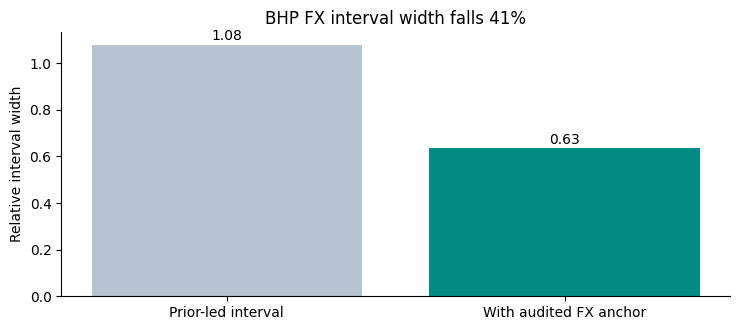

In [6]:
bhp_fx = next(row for row in bhp if row['product'] == 'Cross-border FX')
before = bhp_fx['anchor_impact']['prior_relative_interval_width']
after = bhp_fx['anchor_impact']['anchored_relative_interval_width']
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(['Prior-led interval', 'With audited FX anchor'], [before, after], color=['#B7C2D0', '#008B83'])
ax.set_ylabel('Relative interval width')
ax.set_title(f"BHP FX interval width falls {bhp_fx['anchor_impact']['relative_interval_width_reduction']:.0%}")
ax.spines[['top', 'right']].set_visible(False)
for i, value in enumerate([before, after]): ax.text(i, value + 0.02, f'{value:.2f}', ha='center')
plt.tight_layout()
plt.show()

## 5. Wallet-model validation

The calibration laboratory uses known synthetic truth and client-disjoint conformal calibration/evaluation splits. It validates mechanics and coverage, not empirical client accuracy.

In [7]:
cal = offline['synthetic_calibration']
validation = pd.DataFrame([
    ['Share interval coverage', cal['split_conformal_audit']['share']['conformal_coverage_90'], 0.90, 'Known-truth analog'],
    ['Wallet interval coverage', cal['split_conformal_audit']['wallet']['conformal_coverage_90'], 0.90, 'Known-truth analog'],
    ['E1 median wallet narrowing', cal['comparisons']['e1_anchor_median_wallet_interval_narrowing'], None, 'Anchor stress test'],
    ['Share CRPS improvement', cal['comparisons']['selection_weighted_share_crps_improvement_vs_frozen_prior'], None, 'vs frozen prior'],
], columns=['Metric', 'Result', 'Nominal / target', 'Scope'])
display(validation.style.format({'Result': '{:.1%}', 'Nominal / target': lambda x: '' if pd.isna(x) else f'{x:.0%}'}))
print('Calibration and evaluation entities disjoint:', cal['split_conformal_audit']['calibration_evaluation_entity_disjoint'])
print('Production E3 claim allowed:', cal['production_claim_allowed'])

,Metric,Result,Nominal / target,Scope
0,Share interval coverage,93.5%,90%,Known-truth analog
1,Wallet interval coverage,91.3%,90%,Known-truth analog
2,E1 median wallet narrowing,44.4%,,Anchor stress test
3,Share CRPS improvement,2.9%,,vs frozen prior


Calibration and evaluation entities disjoint: True
Production E3 claim allowed: False


## 6. Sensitivity: does Trade Finance remain dominant?

Two tests answer different questions. The frozen 3x3 benchmark checks continuity across low/base/high priors and rates. The 10,000-draw Latin-hypercube/correlation experiment tests global rank and economic sensitivity.

In [8]:
legacy = pd.DataFrame([{
    'prior': row['prior_case'], 'rate': row['rate_case'],
    'first_product': row['top_product'],
    'TF_top10_share': row['trade_finance_top10_share'],
    'TF_majority': row['trade_finance_dominant'],
    'portfolio_gap_Rm': row['portfolio_gap_p50_zar'] / 1e6,
} for row in portfolio['sensitivity']['scenarios']])
display(legacy.style.format({'TF_top10_share': '{:.0%}', 'portfolio_gap_Rm': '{:.1f}'}))
print('Trade Finance first-ranked:', f"{(legacy.first_product == 'Trade finance').mean():.0%}")
print('Trade Finance majority-dominant:', f"{legacy.TF_majority.mean():.0%}")

,prior,rate,first_product,TF_top10_share,TF_majority,portfolio_gap_Rm
0,low,low,Trade finance,20%,False,219.8
1,low,base,Trade finance,20%,False,522.6
2,low,high,Trade finance,20%,False,1029.8
3,base,low,Trade finance,20%,False,195.8
4,base,base,Trade finance,20%,False,467.2
5,base,high,Trade finance,20%,False,925.4
6,high,low,Trade finance,20%,False,184.4
7,high,base,Trade finance,20%,False,439.1
8,high,high,Trade finance,20%,False,876.1


Trade Finance first-ranked: 100%
Trade Finance majority-dominant: 0%


In [9]:
lhs = fixture['sensitivity']
global_sens = pd.DataFrame([{
    'product': product,
    'first_rank_frequency': metrics['first_rank_frequency'],
    'mean_top10_share': metrics['mean_top10_share'],
    'majority_dominance_frequency': metrics['majority_dominance_frequency'],
    'economics_p50_Rm': metrics['absolute_economics']['p50'] / 1e6,
} for product, metrics in lhs['product_summary'].items()]).sort_values('economics_p50_Rm', ascending=False)
display(global_sens.style.format({
    'first_rank_frequency': '{:.1%}', 'mean_top10_share': '{:.1%}',
    'majority_dominance_frequency': '{:.1%}', 'economics_p50_Rm': '{:.1f}'
}))
print('Conclusion: Trade Finance remains the first-ranked single product in 100% of draws,')
print('but it is never a majority of the top 10. Cross-border FX supplies the broader top-10 concentration.')

,product,first_rank_frequency,mean_top10_share,majority_dominance_frequency,economics_p50_Rm
1,Cross-border FX,0.0%,51.3%,79.7%,57.8
4,Trade finance,100.0%,25.2%,0.0%,53.4
2,Liquidity,0.0%,23.5%,0.0%,34.8
0,Collections,0.0%,0.0%,0.0%,12.8
3,Payments,0.0%,0.0%,0.0%,8.2


Conclusion: Trade Finance remains the first-ranked single product in 100% of draws,
but it is never a majority of the top 10. Cross-border FX supplies the broader top-10 concentration.


## 7. Governed GenAI: extraction and narration cannot publish unsupported facts

GenAI proposes structured candidates and drafts narratives. Deterministic validators own currency, unit, sign, period, arithmetic, duplication, restatement and citation checks. Numbers not present in the approved evidence pack are rejected.

In [10]:
genai_summary = pd.DataFrame([
    ['Golden-set cases', genai['dataset_cases'], 'sealed train/dev/test protocol'],
    ['Governed checks', genai['governed_evaluation_checks'], 'schema + evidence + page grounding + stress'],
    ['Schema compliance', genai['schema_compliance'], 'deterministic baseline'],
    ['Evidence facts replayed', genai['evidence_register_replay']['facts'], '82/82 passed'],
    ['Stress cases', genai['generated_stress_suite']['cases'], 'exact/future/injection/missing'],
    ['Stress failures', genai['generated_stress_suite']['failures'], 'zero'],
], columns=['Control', 'Result', 'Interpretation'])
display(genai_summary)
print('Approved live-provider production release:', genai['release_gate']['production_release_allowed'])

,Control,Result,Interpretation
0,Golden-set cases,36.0,sealed train/dev/test protocol
1,Governed checks,809.0,schema + evidence + page grounding + stress
2,Schema compliance,1.0,deterministic baseline
3,Evidence facts replayed,82.0,82/82 passed
4,Stress cases,640.0,exact/future/injection/missing
5,Stress failures,0.0,zero


Approved live-provider production release: False


## 8. Timing and causal boundary

Transaction-derived events can support a transparent timing baseline, but they are not RM recommendation/action/outcome labels. The system therefore refuses to claim uplift or causal incremental value.

In [11]:
timing = offline['historical_validation']['timing_surrogate']
trial = manifest['trial_analog']
boundary = pd.DataFrame([
    ['Start-stop intervals', timing['start_stop_intervals'], 'Transaction-derived surrogate'],
    ['Qualified RM outcomes', timing['qualified_rm_action_gate']['outcome_events'], 'Promotion gate remains closed'],
    ['Trial analog opportunities', trial['eligible_opportunities'], 'Synthetic instrumentation rehearsal'],
    ['Trial analog clusters', trial['clusters'], 'Synthetic cluster design'],
], columns=['Item', 'Count', 'Claim boundary'])
display(boundary)
print('Timing promotion decision:', timing['decision'])
print('Causal uplift label allowed:', manifest['claim_boundary']['causal_uplift_label_allowed'])

,Item,Count,Claim boundary
0,Start-stop intervals,3440,Transaction-derived surrogate
1,Qualified RM outcomes,0,Promotion gate remains closed
2,Trial analog opportunities,1500,Synthetic instrumentation rehearsal
3,Trial analog clusters,30,Synthetic cluster design


Timing promotion decision: RETAIN_SEASONAL_BASELINE
Causal uplift label allowed: False


## 9. Judge-facing conclusion

The system is ready for a governed hackathon/client demonstration: it ranks a concrete conversation, shows the uncertainty around it, traces the evidence and reports when sensitivity changes the portfolio conclusion. It is intentionally not labelled bank-production-ready. The remaining external gates are real E3 multibank calibration, approved bank economics, finance-SME approval, bank identity/infrastructure, live-provider adjudication and an RM trial.